In [ ]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 12 ,
    "legend.title_fontsize": 15,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "savefig.dpi": 600,
    "figure.dpi": 600
})


In [140]:
# ======================
# 0) 需要你改的参数（只改路径/刷新频率就够）
# ======================
DOSE = ["00","05","10","30","50"]

# sitesresult 文件名模板：默认 sitesresult00.csv ... sitesresult50.csv
SITESRESULT_TEMPLATE = "{dose}/sitesresult{dose}.csv"

# 刷新频率（秒）
REFRESH_SECONDS = 2.0


## 1) GB 平面与 MC 设置（原样保留自 `siteprocessauto.ipynb`）

In [141]:
import pandas as pd
A = -0.5488
B = -3.4971
C = -1.0
D = -0.5488*0.002 - 3.4971*0.0005 - 0.002 + 0.0076

# ---- box & MC settings ----
L = 1e-3
N_mc = 5_000_000
rng = np.random.default_rng(123)
reuse_points = rng.random((N_mc, 3)) * L  # 所有 bin 复用同一批点（更快更稳）

## 2) slab_volume_mc（原样保留自 `siteprocessauto.ipynb`）

In [142]:
def slab_volume_mc(d0, thickness, A, B, C, D, L=1e-3, reuse_points=None, N_mc=2_000_000, seed=123):
    """
    Return volume of slab (signed distance in [d0-th/2, d0+th/2]) inside cube [0,L]^3.
    """
    if thickness <= 0:
        return 0.0

    norm = np.sqrt(A*A + B*B + C*C)
    dmin = d0 - 0.5 * thickness
    dmax = d0 + 0.5 * thickness
    V_box = L**3

    if reuse_points is None:
        rng = np.random.default_rng(seed)
        reuse_points = rng.random((N_mc, 3)) * L

    pts = reuse_points
    dist = (A*pts[:,0] + B*pts[:,1] + C*pts[:,2] + D) / norm
    return V_box * ((dist >= dmin) & (dist < dmax)).mean()


In [143]:
# ======================
# 3) 单个 dose 的“旧逻辑”后处理：sitesresult -> density_df
#    （从旧 notebook 的 cell1 + cell4 拼接，但不落盘）
# ======================

def process_one_dose(dose_str: str) -> pd.DataFrame:
    csv_path = SITESRESULT_TEMPLATE.format(dose=dose_str)

    raw = pd.read_csv(csv_path, header=None)

    # 只取前 4 列（防止后面还有其它列）
    raw = raw.iloc[:, :4].copy()
    raw.columns = ["type_or_elem", "x", "y", "z"]

    # 判断第一列是数字还是字符串
    if pd.api.types.is_numeric_dtype(raw["type_or_elem"]):
        raw = raw.rename(columns={"type_or_elem": "type"})
        type_map = {1: "Si", 2: "Cr", 3: "Ni"}  # 你说的：type==3 是 Ni
        raw["elem"] = raw["type"].map(type_map).fillna(raw["type"].astype(int).astype(str))
    else:
        raw = raw.rename(columns={"type_or_elem": "elem"})

    df = raw

    # ---- signed distance ----
    norm = np.sqrt(A**2 + B**2 + C**2)
    df["dist_signed"] = (A*df["x"] + B*df["y"] + C*df["z"] + D) / norm
    df["dist_abs"] = df["dist_signed"].abs()

    # ---- binning (原样) ----
    thickness_local = 2e-6
    centers = np.arange(-2e-5, 2e-5, thickness_local)
    bin_edges = np.concatenate(([centers[0] - 0.5*thickness_local], centers + 0.5*thickness_local))

    df["dist_bin_center"] = pd.cut(
        df["dist_signed"],
        bins=bin_edges,
        labels=centers,
        include_lowest=True,
        right=False,
    )

    _df_in = df.dropna(subset=["dist_bin_center"]).copy()

    count_table = (
        _df_in.pivot_table(index="dist_bin_center", columns="elem", aggfunc="size", fill_value=0)
            .sort_index()
    )
    count_table = count_table.reindex(centers, fill_value=0)
    count_table.index.name = "dist_signed_bin_center"

    # ---- 旧 cell4 的逻辑：把 index 变成列，再算 slab_volume & density ----
    out = count_table.reset_index()  # dist_signed_bin_center 变成列

    # 你的 bin 厚度：旧脚本里就是 thickness 变量（常数 3e-6）
    thickness = thickness_local
    out["thickness"] = thickness

    out["slab_volume"] = out["dist_signed_bin_center"].apply(
        lambda d0: slab_volume_mc(d0, thickness, A, B, C, D, L=L, reuse_points=reuse_points)
    )

    for col in ["Cr", "Ni", "O", "Si"]:
        if col not in out.columns:
            out[col] = 0
        out[f"density_{col}"] = out[col] * 1e-12 / out["slab_volume"]

    return out


## 4) 绘图逻辑（原样保留自 `draw.ipynb`，但数据来自内存而不是 csv 文件）

In [144]:
# draw.ipynb 的工具函数（原样复制）
import re

def pick_distance_col(df: pd.DataFrame) -> str:
    candidates = [
        "dist_signed_bin_center", "dist_bin_center", "distance", "dist", "x", "r"
    ]
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return cols[0]

def pick_density_col(df: pd.DataFrame, element: str) -> str:
    preferred = f"density_{element}"
    if preferred in df.columns:
        return preferred

    el = element.lower()
    cols = list(df.columns)
    scored = []
    for c in cols:
        cl = c.lower()
        if el in cl:
            score = 0
            if "density" in cl: score += 3
            if "conc" in cl or "concentration" in cl: score += 2
            if "frac" in cl or "at%" in cl or "wt%" in cl: score += 1
            scored.append((score, c))
    if scored:
        scored.sort(reverse=True)
        return scored[0][1]

    raise ValueError(f"Cannot find concentration/density column for {element} in columns: {cols}")

MM_TO_NM = 1000000.0
elements = ["Cr", "Ni", "Si"]

def plot_all_doses(dose_dfs: dict[float, pd.DataFrame]):
    doses_sorted = sorted(dose_dfs.keys())
    for element in elements:
        plt.figure(figsize=(7.5, 5.0))
        for dose in doses_sorted:
            df = dose_dfs[dose]
            xcol = pick_distance_col(df)
            ycol = pick_density_col(df, element)

            x_um = df[xcol].astype(float) * MM_TO_NM
            y = df[ycol].astype(float)

            plt.plot(x_um, y, marker="o", linewidth=1.5, label=f"{dose:.1f} dpa")

        plt.axvline(0.0, linestyle="--", linewidth=1.0)
        plt.xlabel("Distance to GB (nm)")
        plt.ylabel(f"{element} concentration (at%)")
        plt.title(f"{element}: concentration vs. distance to GB")
        plt.legend(title="Dose", ncol=2)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


## 5) 实时监控循环（只加 while，不改数值逻辑）

In [145]:
def monitor_loop():
    # dose_str -> (mtime, size)
    last_state = {d: (None, None) for d in DOSE}

    # dose(float dpa) -> processed dataframe
    dose_dfs = {}

    while True:
        updated_any = False
        missing = []

        for d in DOSE:
            path = SITESRESULT_TEMPLATE.format(dose=d)
            if not os.path.exists(path):
                missing.append(d)
                continue

            try:
                mtime = os.path.getmtime(path)
                fsize = os.path.getsize(path)
            except OSError:
                continue

            prev_mtime, prev_size = last_state[d]
            if (prev_mtime is None) or (mtime != prev_mtime) or (fsize != prev_size):
                # 该 dose 文件更新：按旧逻辑重算
                try:
                    out = process_one_dose(d)
                    dose_float = int(d) / 10.0
                    dose_dfs[dose_float] = out
                    last_state[d] = (mtime, fsize)
                    updated_any = True
                except Exception as e:
                    # 写入过程中半行导致 read_csv 失败：下次循环重试
                    pass

        if updated_any or (not dose_dfs):
            clear_output(wait=True)
            print("[monitor] updated:", time.strftime('%Y-%m-%d %H:%M:%S'))
            if missing:
                print("[monitor] missing:", missing)

            if dose_dfs:
                plot_all_doses(dose_dfs)
            else:
                print("No dataframes available yet (all files missing or unreadable).")

        time.sleep(REFRESH_SECONDS)


[monitor] updated: 2026-02-12 20:21:14


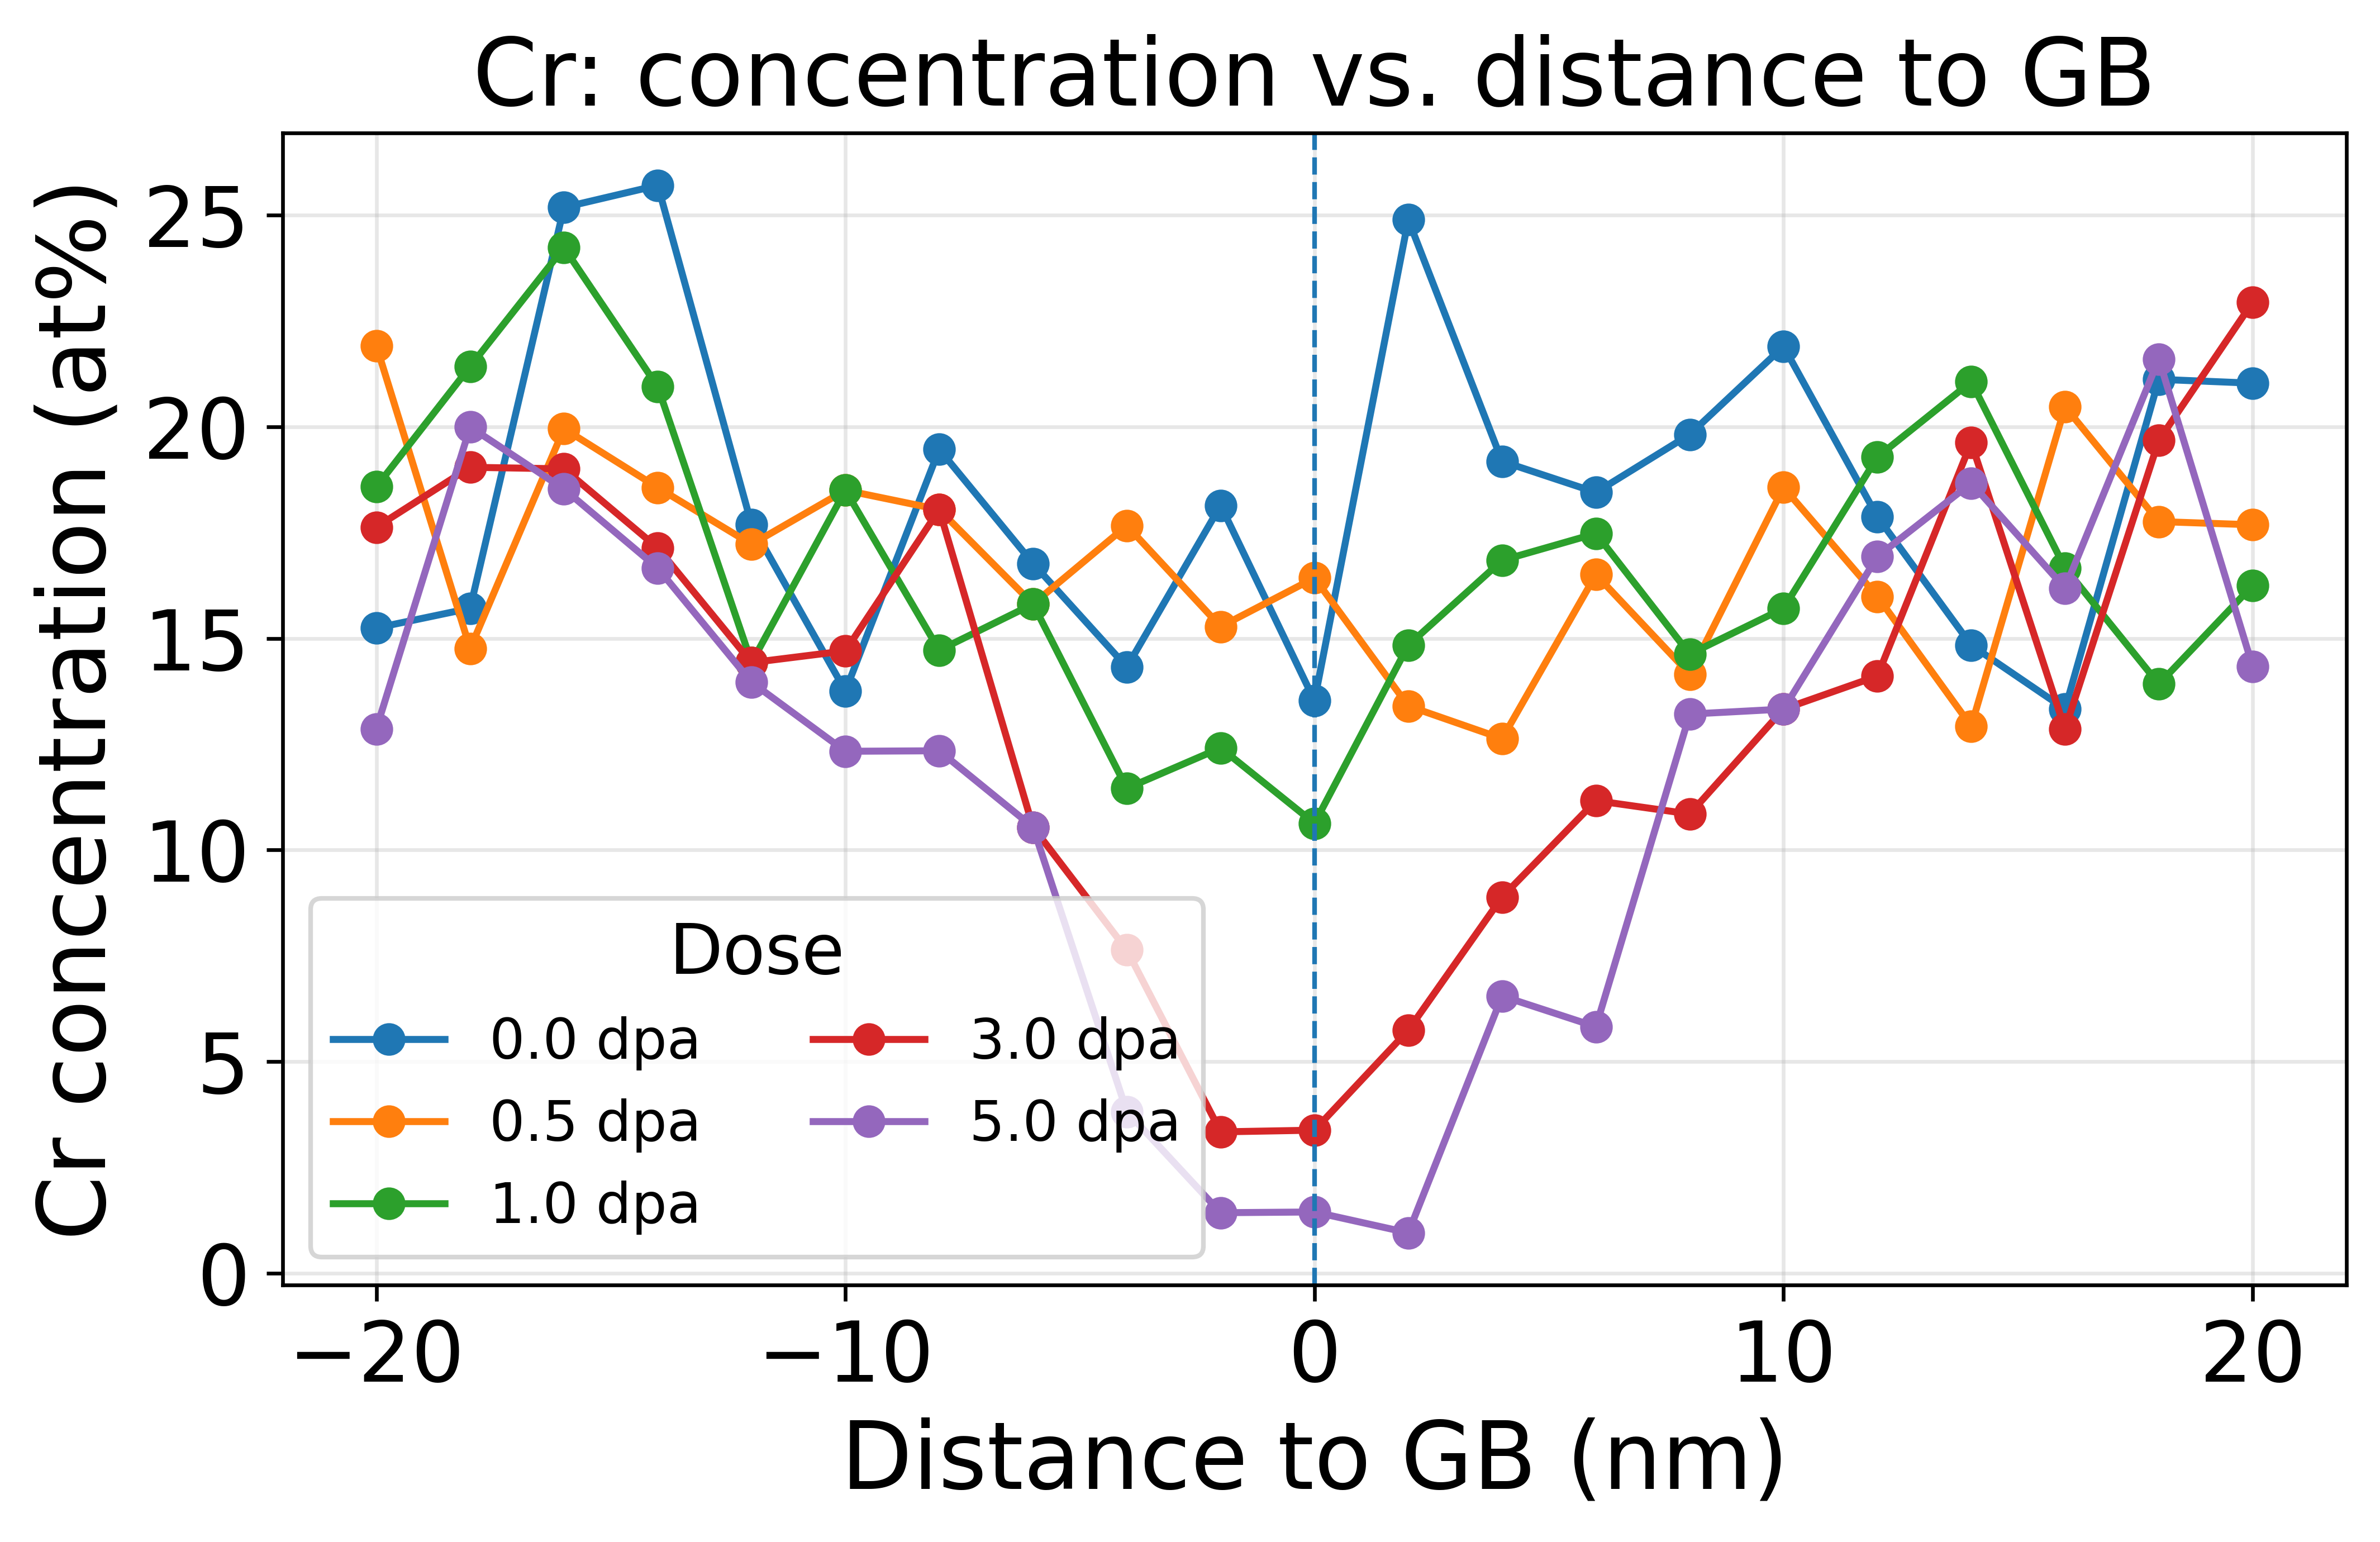

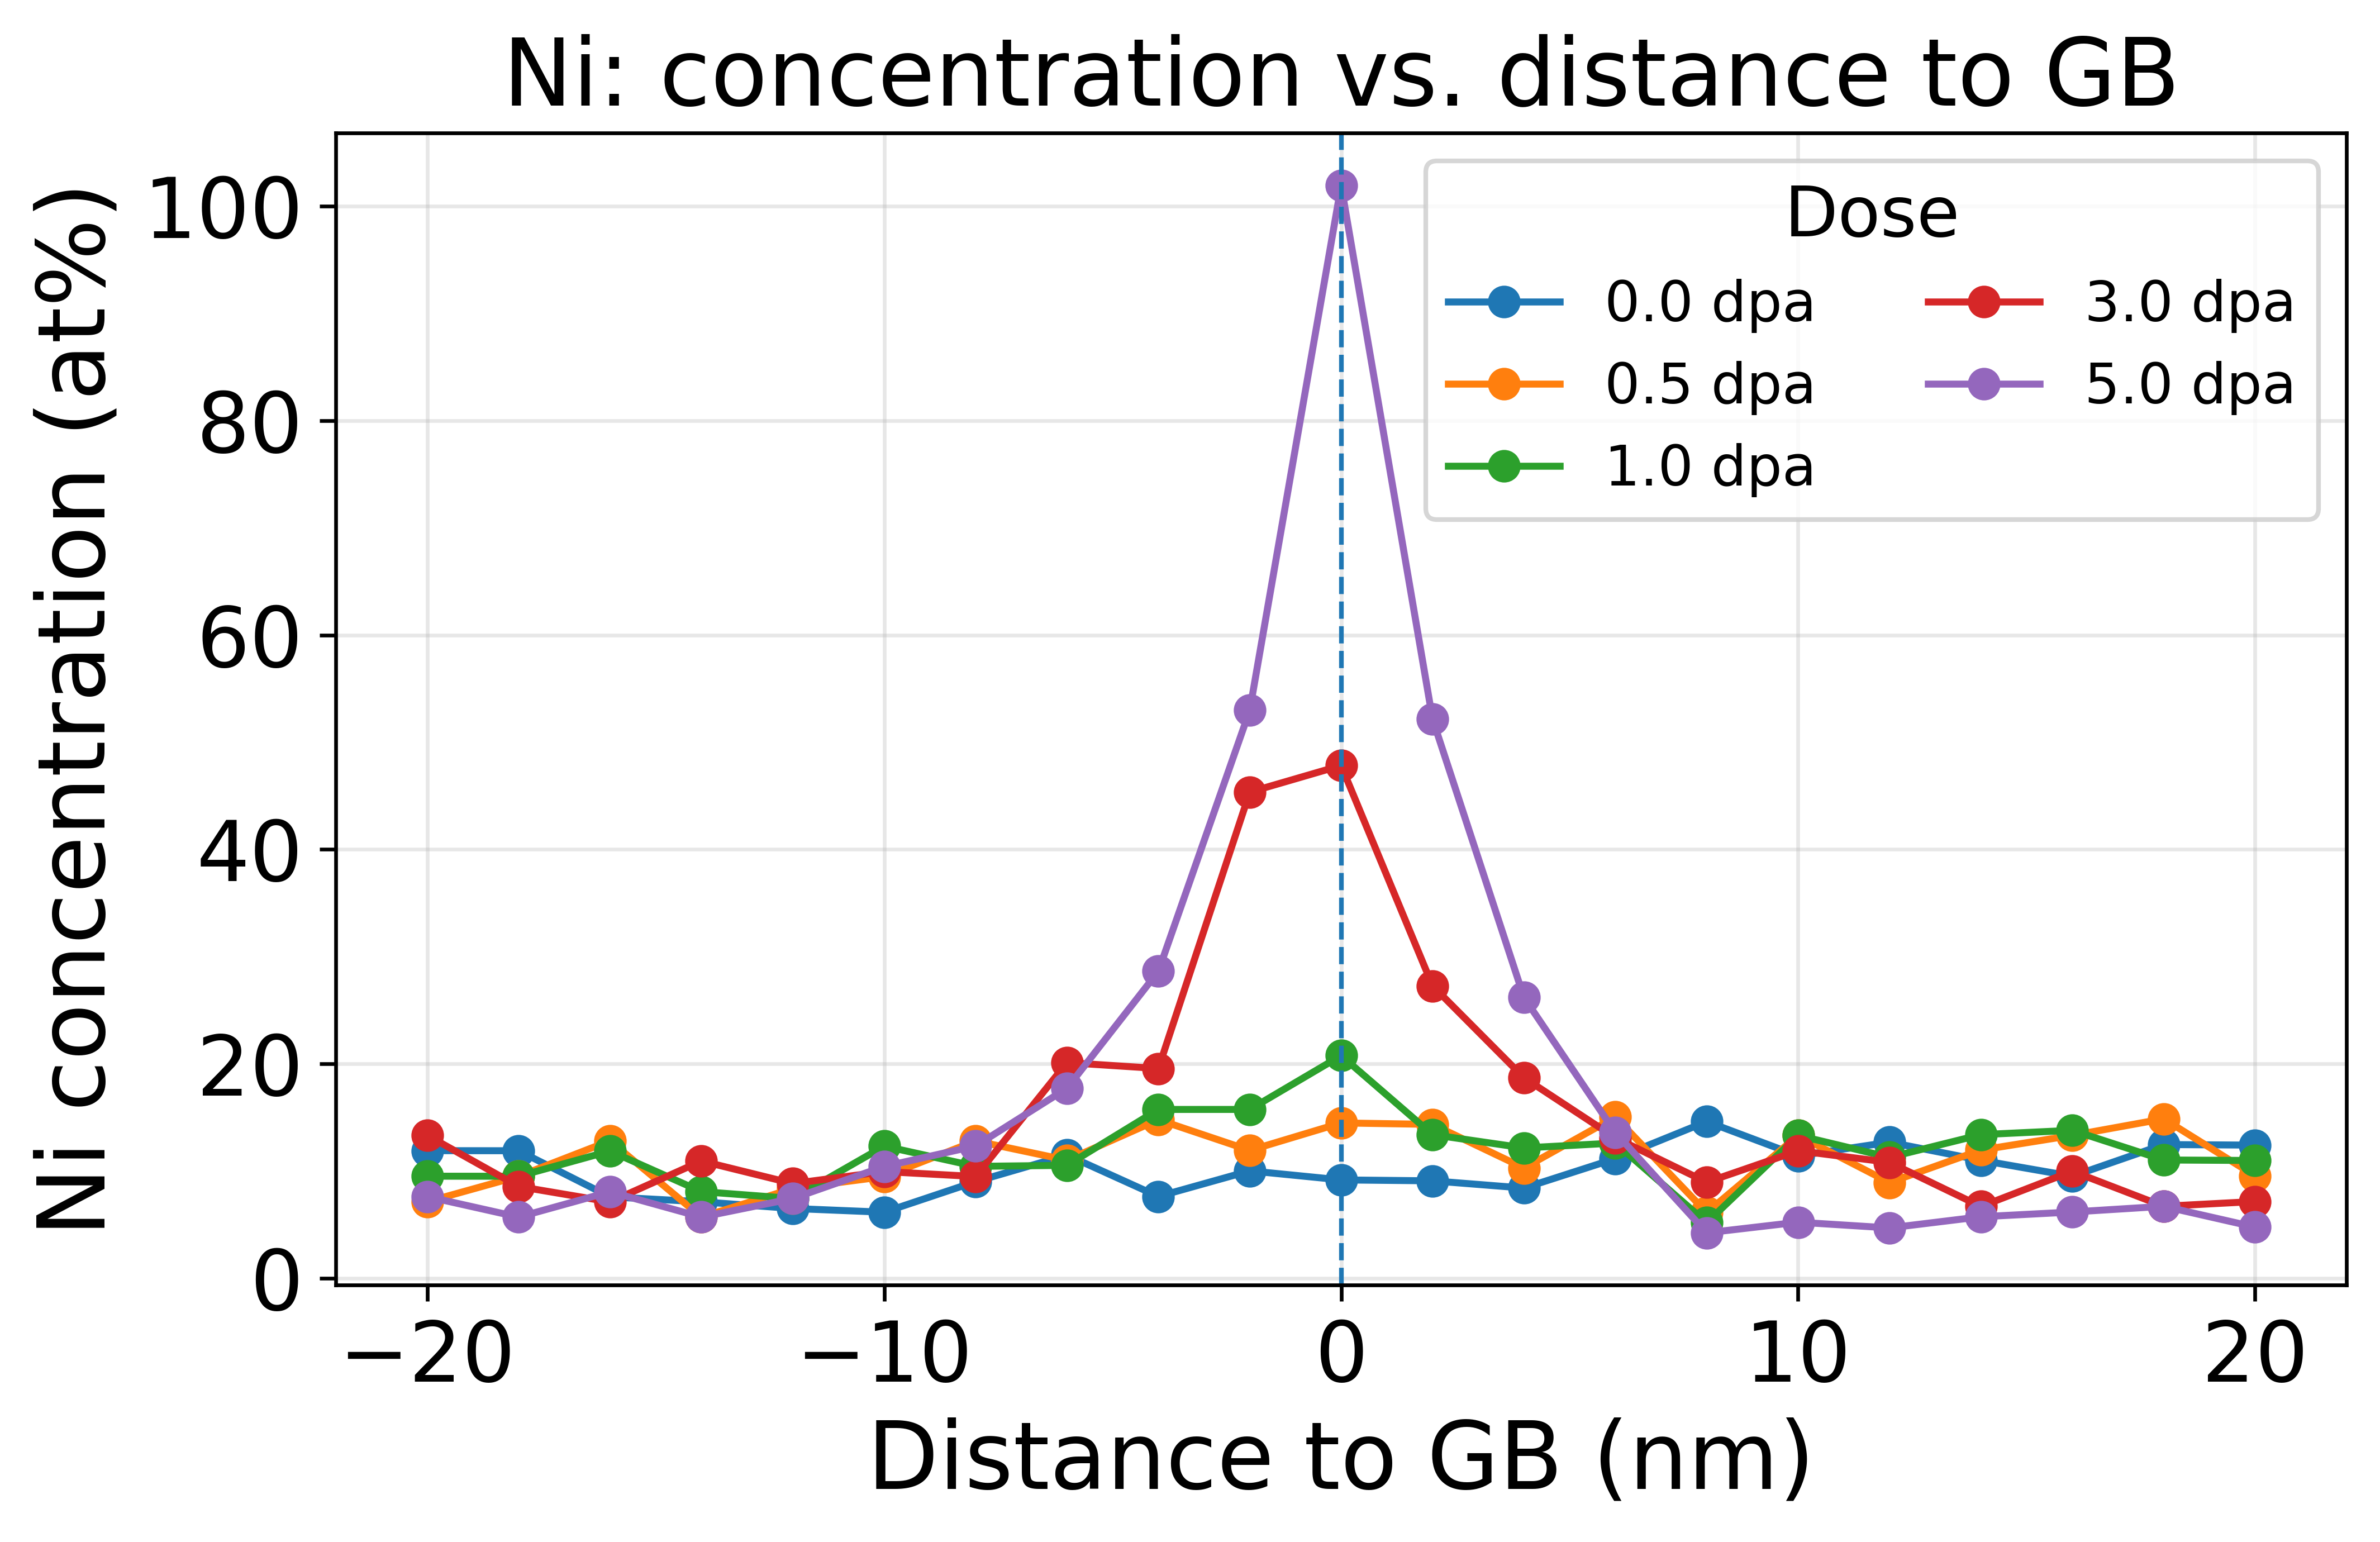

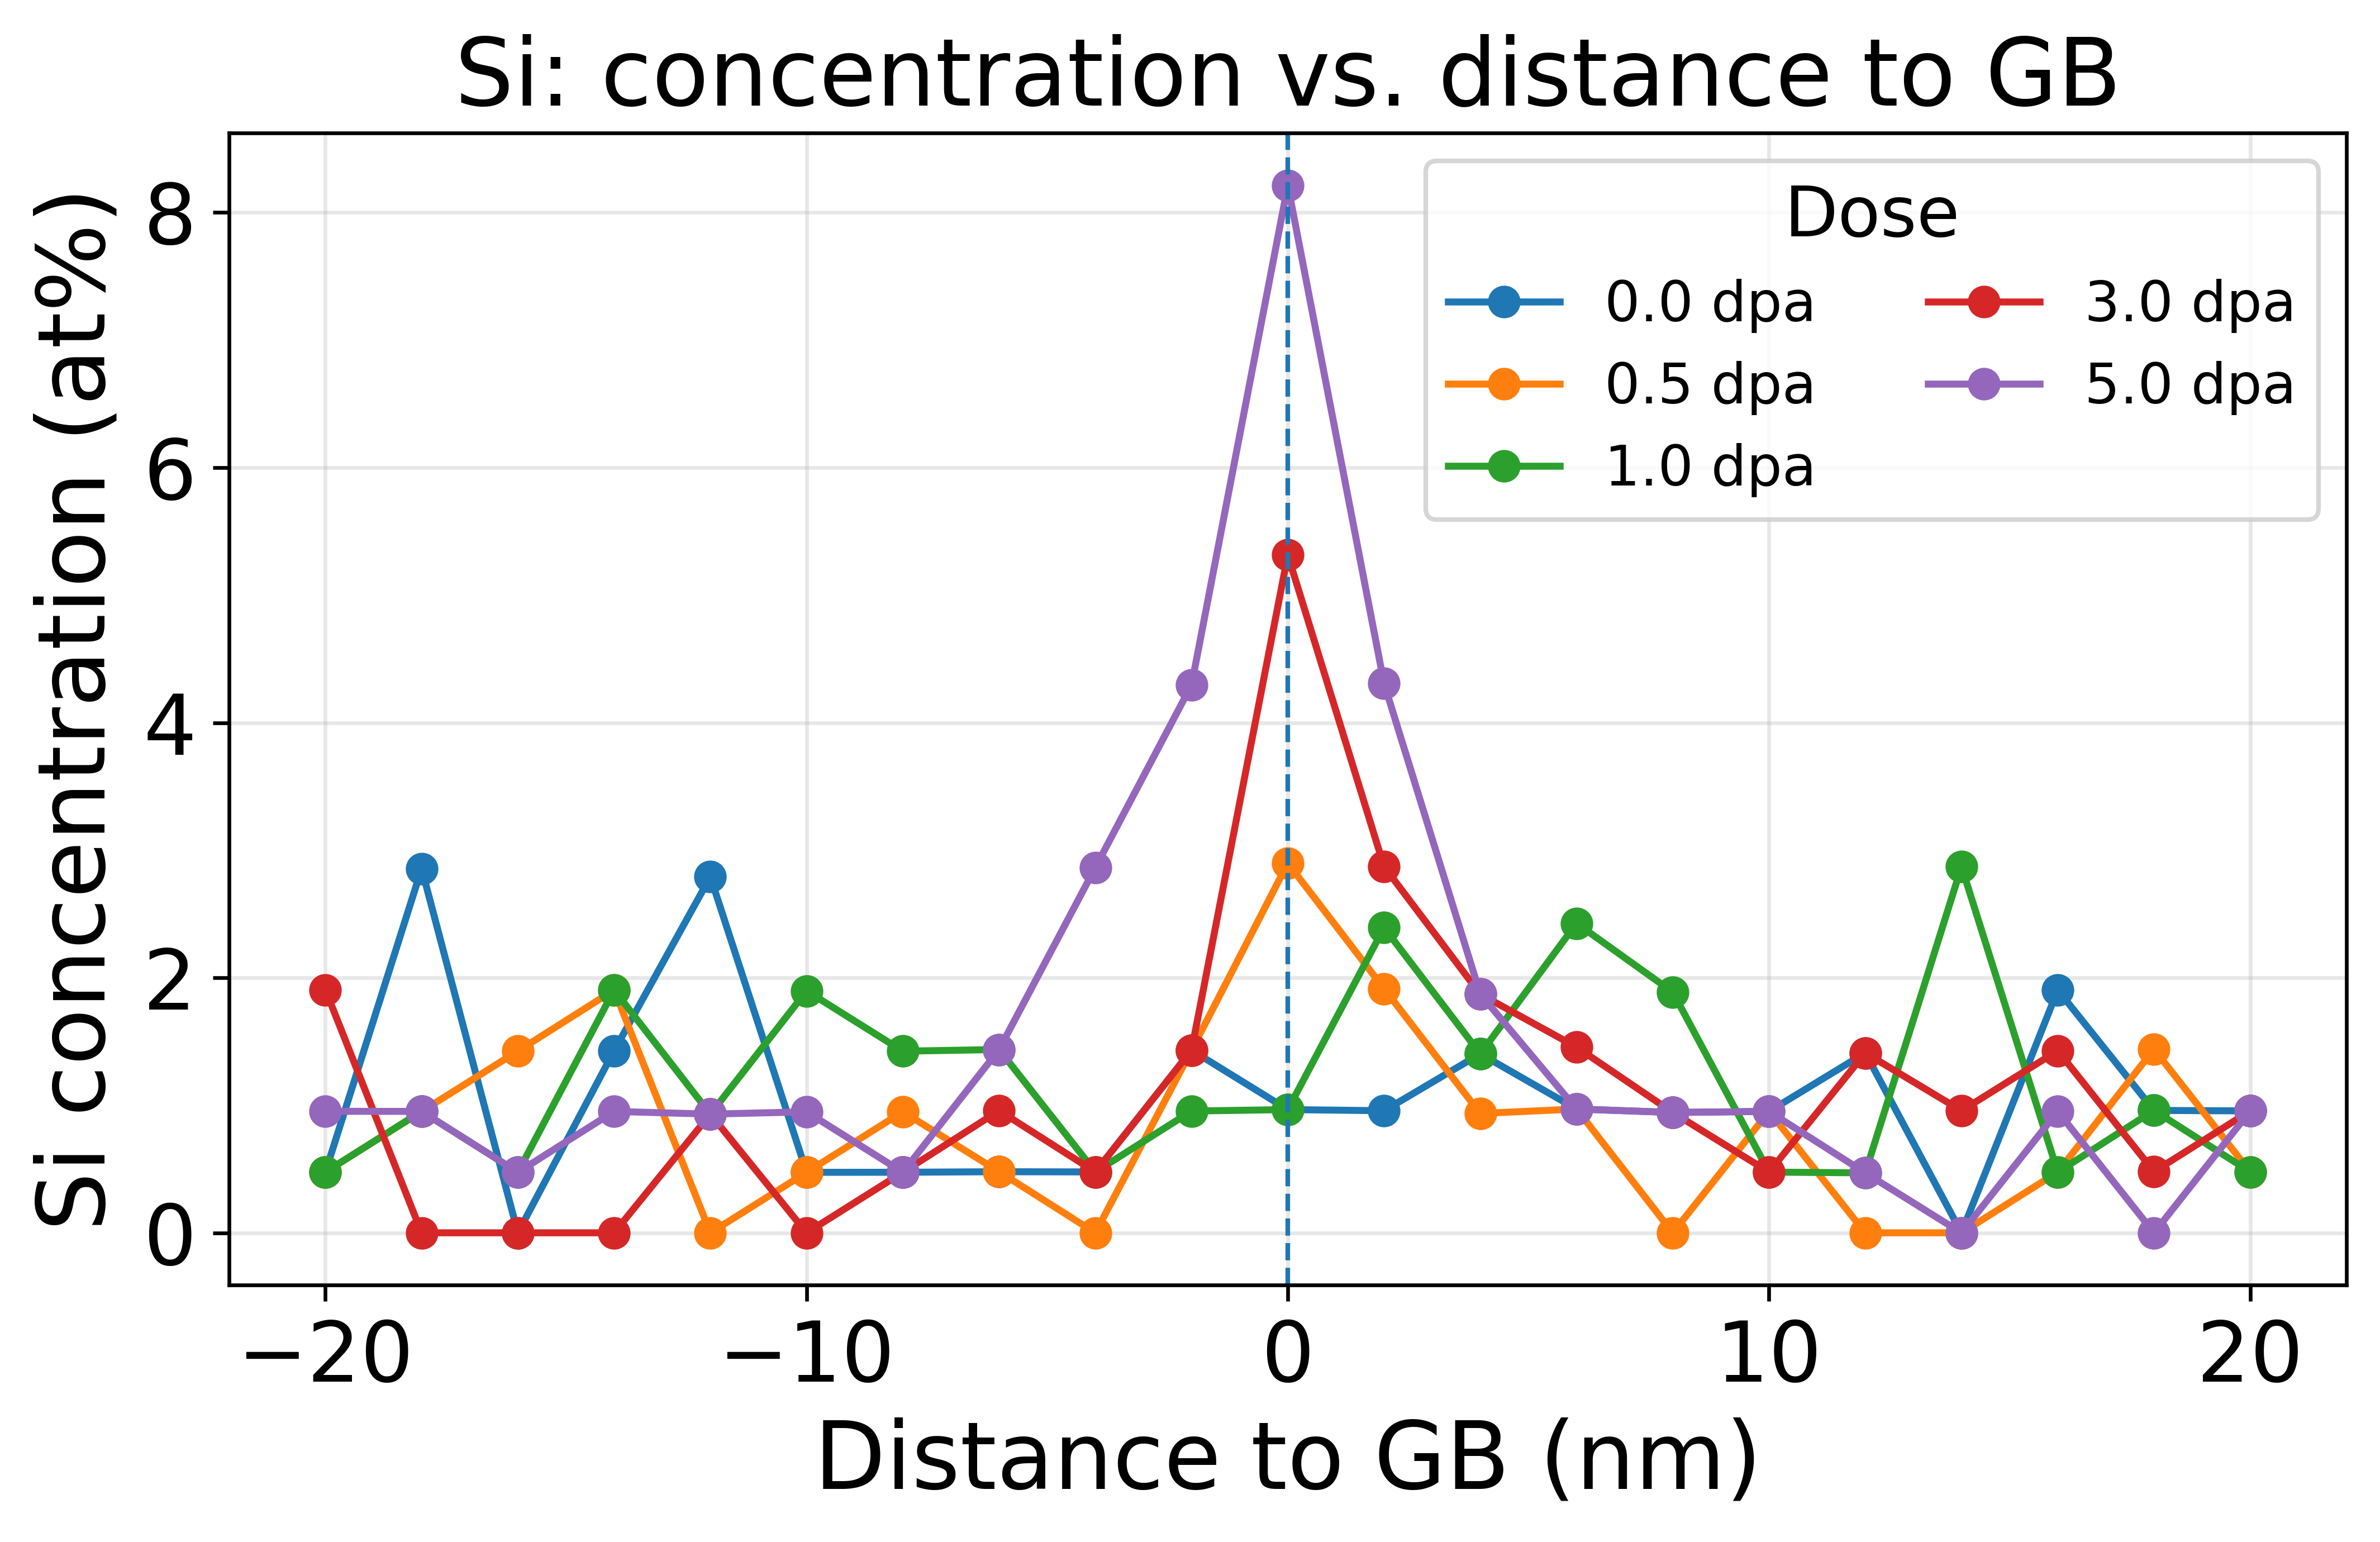

KeyboardInterrupt: 

In [146]:
# ======================
# 6) 启动（运行此格）
# ======================
monitor_loop()
